In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00         SAO   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00         SAO   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00         SAO   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00         SAO   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00         SAO   
...               ...       ...        ...                  ...         ...   
14495830  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
14495831  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
14495832  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
14495833  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
14495834  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

          HourlyDewPointTemperature  HourlyDryBulbT

In [3]:
# Exclude days from April through October (months 4-10) in CV_rows
CV_rows = CV_rows[~CV_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_rows after removing April-October:", CV_rows.shape)

CV_rows after removing April-October: (6404926, 19)


In [4]:
CV_rows['HourlyDewpointDepression'] = (
    CV_rows['HourlyDryBulbTemperature'] - CV_rows['HourlyDewPointTemperature']
)

CV_rows[['HourlyDryBulbTemperature', 'HourlyDewPointTemperature', 'HourlyDewpointDepression']].head()

,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlyDewpointDepression
0,13.0,11.9,1.1
1,12.4,10.7,1.7
2,12.4,11.3,1.1
3,12.4,11.3,1.1
4,13.0,11.9,1.1


In [5]:
# Ensure wind direction is numeric; "000" is treated as calm (0, 0)
wd1 = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")

# Unit-vector style components from wind direction
# 360 = north, 180 = south, 270 = west, 90 = east
# Determine the north-south component of the wind direction
CV_rows["wind_ns_component"] = np.where(
    wd1.eq(0) | wd1.isna(),
    0.0,
    np.cos(np.deg2rad(wd1))
)

# Determine west-east component of the wind direction
CV_rows["wind_we_component"] = np.where(
    wd1.eq(0) | wd1.isna(),
    0.0,
    np.sin(np.deg2rad(wd1))
)

CV_rows[["HourlyWindDirection", "wind_ns_component", "wind_we_component"]].head()

,HourlyWindDirection,wind_ns_component,wind_we_component
0,0.0,0.000000,0.000000
1,158.0,-0.927184,0.374607
2,0.0,0.000000,0.000000
3,225.0,-0.707107,-0.707107
4,225.0,-0.707107,-0.707107


In [6]:
# Classify each observation as up-valley or down-valley relative to valley angle = 330°
valley_angle = 330.0  # interpreted as the up-valley flow direction (toward 330°)

wd = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")  # meteorological "from" direction
ws = pd.to_numeric(CV_rows["HourlyWindSpeed"], errors="coerce")

# Convert to "to" direction (direction wind is blowing toward)
wd_to = (wd + 180.0) % 360.0

# Signed alignment with valley axis (+ up-valley, - down-valley)
# cos(delta) > 0 means aligned with up-valley axis, < 0 means opposite (down-valley)
delta = np.deg2rad(wd_to - valley_angle)
valley_alignment = np.cos(delta)

# Optional speed-weighted along-valley component
CV_rows["valley_along_component"] = valley_alignment * ws

calm_mask = wd.eq(0) | ws.eq(0)  # "000" direction and/or zero speed => calm
missing_mask = wd.isna() | ws.isna()

# Classify each observation as "up_valley", "down_valley", "cross_valley", "calm", or "missing"
CV_rows["valley_wind_type"] = np.select(
    [
        missing_mask,
        calm_mask,
        valley_alignment > 0,
        valley_alignment < 0,
    ],
    [
        "missing",
        "calm",
        "up_valley",
        "down_valley",
    ],
    default="cross_valley",
)

# Quick station-level check of the counts of each valley wind type
station_valley_counts = (
    CV_rows.groupby(["STATION", "valley_wind_type"])
    .size()
    .unstack(fill_value=0)
)

station_valley_counts.head()

valley_wind_type,calm,down_valley,up_valley
STATION,,,
BAKERSFIELD AP,93181,160509,132605
BEALE AFB,70007,94808,152317
CASTLE AFB,124287,88552,89316
CHICO ARMY FLYING SCHOOL,61822,61995,74061
FRESNO,1350,13684,9917


In [7]:
# Print all column names from CV_rows

CV_rows.head()

,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyPresentWeatherType,HourlySkyConditions,...,month,day,hour,minute,STATION,HourlyDewpointDepression,wind_ns_component,wind_we_component,valley_along_component,valley_wind_type
0,USM00074917,35.117,-119.3,1941-12-01 00:00:00,SAO,11.9,13.0,0.0,||00,BKN:06,...,12,1,0,0,GARDNER AAF,1.1,0.000000,0.000000,-0.000000,calm
1,USM00074917,35.117,-119.3,1941-12-01 01:00:00,SAO,10.7,12.4,0.0,||00,OVC:08,...,12,1,1,0,GARDNER AAF,1.7,-0.927184,0.374607,0.495134,up_valley
2,USM00074917,35.117,-119.3,1941-12-01 02:00:00,SAO,11.3,12.4,0.0,||00,OVC:08,...,12,1,2,0,GARDNER AAF,1.1,0.000000,0.000000,-0.000000,calm
3,USM00074917,35.117,-119.3,1941-12-01 03:00:00,SAO,11.3,12.4,0.0,||00,OVC:08,...,12,1,3,0,GARDNER AAF,1.1,-0.707107,-0.707107,0.129410,up_valley
4,USM00074917,35.117,-119.3,1941-12-01 04:00:00,SAO,11.9,13.0,0.0,||00,OVC:08,...,12,1,4,0,GARDNER AAF,1.1,-0.707107,-0.707107,0.129410,up_valley


In [17]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_wind_filtered = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 4.6)
    & (CV_rows["HourlyWindSpeed"] < 2.000)
]

print("CV_filtered_rows:", CV_rows_dd_wind_filtered.shape)

CV_filtered_rows: (1750733, 24)


In [9]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_5deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 4.6)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_5deg.shape)

CV_filtered_rows: (246441, 24)


In [10]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_4deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 4)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_4deg.shape)

CV_filtered_rows: (245852, 24)


In [11]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_3deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 3)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_3deg.shape)

CV_filtered_rows: (242934, 24)


In [12]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_2deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 2)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_2deg.shape)

CV_filtered_rows: (233179, 24)


In [13]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_1deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 1)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_1deg.shape)

CV_filtered_rows: (181694, 24)


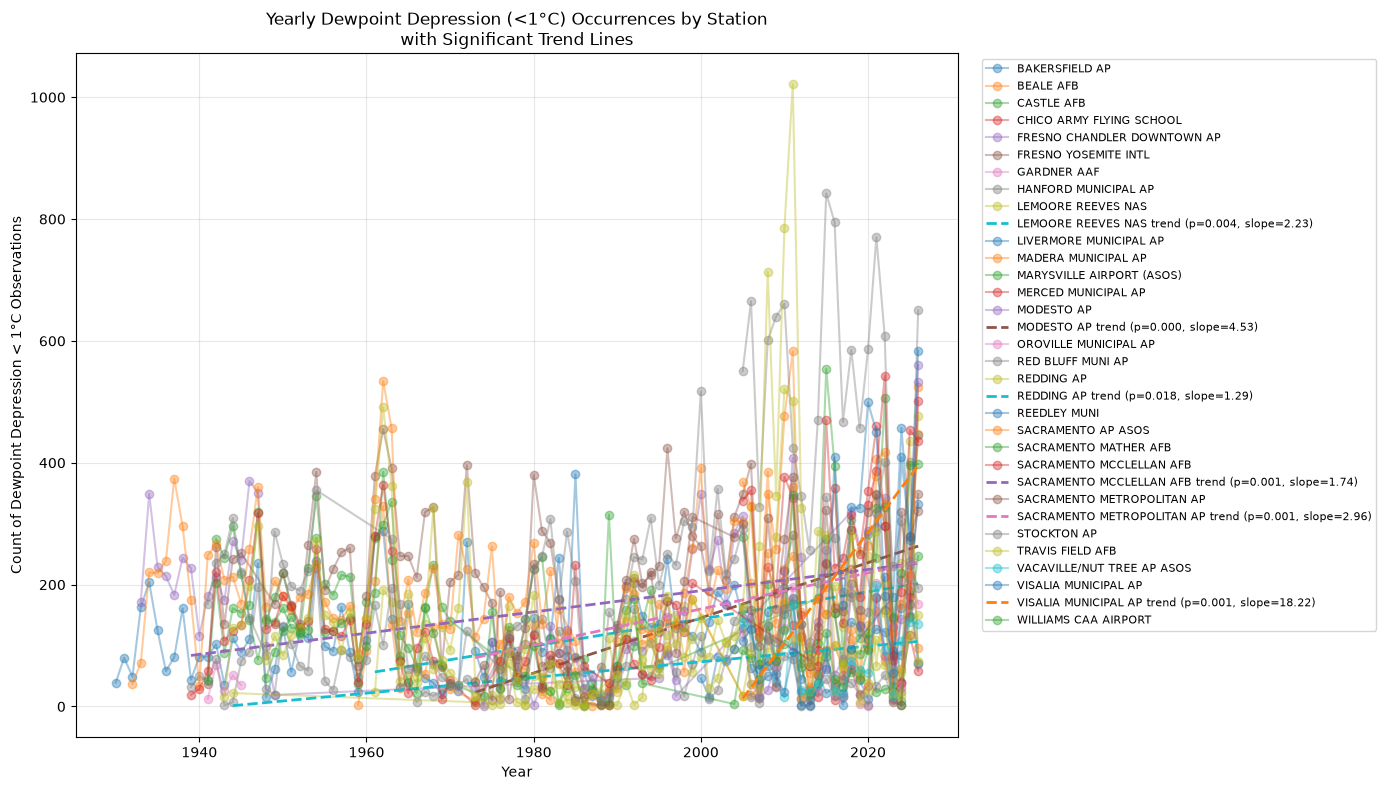

In [14]:
# Plot dewpoint depression occurrences per year for each station (CV_rows_dd_filtered_1deg)
# Fit and plot trend lines only for stations with statistically significant trends (p < 0.05)

yearly_counts = (
    CV_rows_dd_filtered_1deg.groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

stations = yearly_counts["STATION"].unique()

fig, ax = plt.subplots(figsize=(14, 8))

for station in stations:
    station_data = yearly_counts[yearly_counts["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    # Plot the raw yearly counts
    ax.plot(x, y, marker='o', linestyle='-', alpha=0.4, label=f"{station}")

    # Fit linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Only plot trend line if significant (p < 0.05)
    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(x, trend_y, linestyle='--', linewidth=2,
                label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})")

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 1°C Observations")
ax.set_title("Yearly Dewpoint Depression (<1°C) Occurrences by Station\nwith Significant Trend Lines")
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

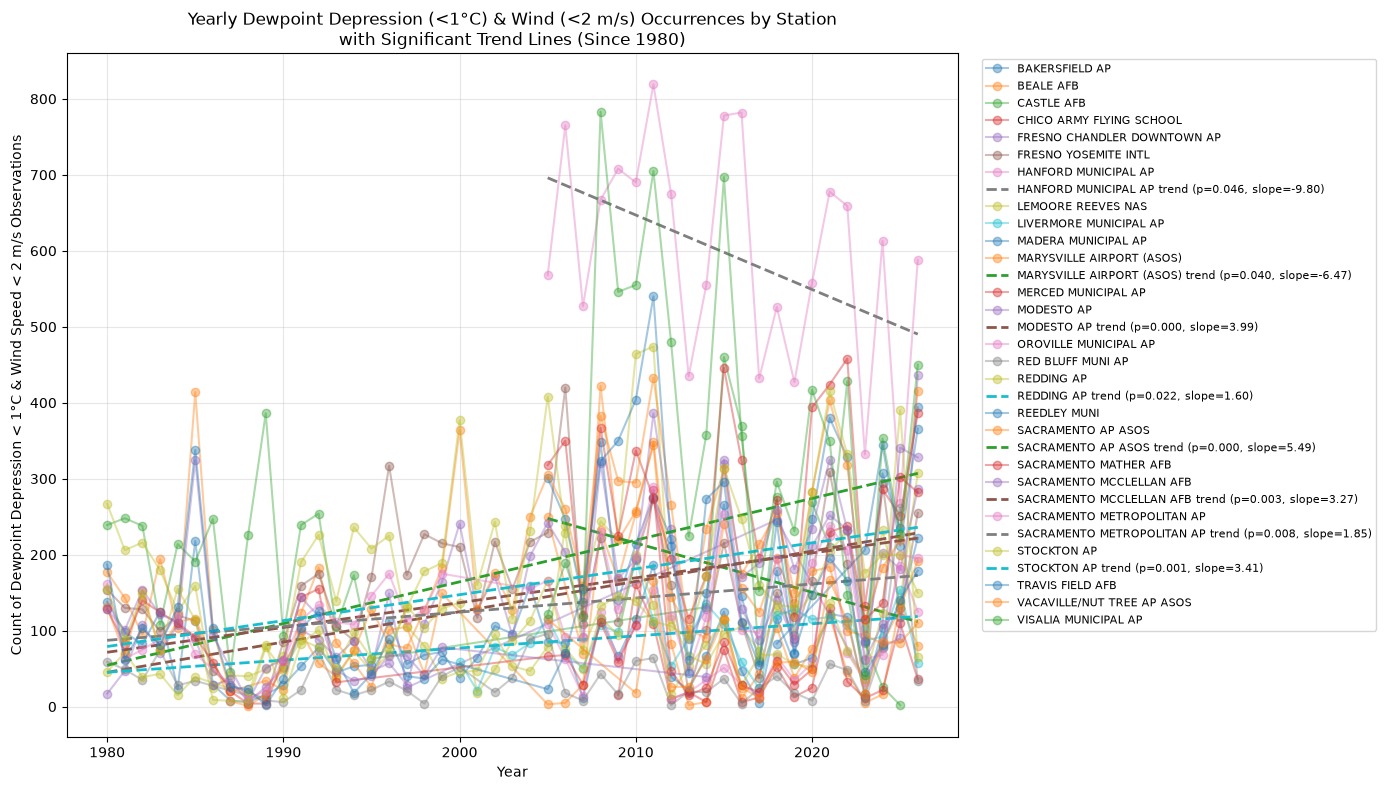

In [16]:
# Plot dewpoint depression occurrences per year for each station (CV_rows_dd_wind_filtered)
# Fit and plot trend lines only for stations with statistically significant trends (p < 0.05), since 1980

yearly_counts_wind = (
    CV_rows_dd_wind_filtered[CV_rows_dd_wind_filtered['year'] >= 1980]
    .groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

stations_wind = yearly_counts_wind["STATION"].unique()

fig, ax = plt.subplots(figsize=(14, 8))

for station in stations_wind:
    station_data = yearly_counts_wind[yearly_counts_wind["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    # Plot the raw yearly counts
    ax.plot(x, y, marker='o', linestyle='-', alpha=0.4, label=f"{station}")

    # Fit linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Only plot trend line if significant (p < 0.05)
    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(x, trend_y, linestyle='--', linewidth=2,
                label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})")

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 1°C & Wind Speed < 2 m/s Observations")
ax.set_title("Yearly Dewpoint Depression (<1°C) & Wind (<2 m/s) Occurrences by Station\nwith Significant Trend Lines (Since 1980)")
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Compare CV_rows to CV_rows_dd_wind_filtered to determine the number of days/observations with optimal fog conditions
total_obs = CV_rows.shape[0]
optimal_obs = CV_rows_dd_wind_filtered.shape[0]

print(f"Total observations: {total_obs}")
print(f"Observations with optimal fog conditions (dewpoint depression < 4.6 & wind speed < 2 m/s): {optimal_obs}")
print(f"Percentage of optimal fog condition observations: {optimal_obs / total_obs * 100:.2f}%")

# Count unique days (based on year, month, day) with at least one optimal fog observation
optimal_days = CV_rows_dd_wind_filtered[["year", "month", "day"]].drop_duplicates().shape[0]
total_days = CV_rows[["year", "month", "day"]].drop_duplicates().shape[0]

print(f"\nTotal unique days in dataset: {total_days}")
print(f"Unique days with at least one optimal fog condition observation: {optimal_days}")
print(f"Percentage of days with optimal fog conditions: {optimal_days / total_days * 100:.2f}%")

Total observations: 6404926
Observations with optimal fog conditions (dewpoint depression < 4.6 & wind speed < 2 m/s): 1750733
Percentage of optimal fog condition observations: 27.33%

Total unique days in dataset: 22534
Unique days with at least one optimal fog condition observation: 18522
Percentage of days with optimal fog conditions: 82.20%


In [20]:
# Fraction of rows in the optimal fog dataset that have visibility < 1
optimal_rows = CV_rows_dd_wind_filtered.copy()

vis_lt_1_rows = optimal_rows[optimal_rows["HourlyVisibility"] < 1].copy()
frac_rows_vis_lt_1 = vis_lt_1_rows.shape[0] / optimal_rows.shape[0]

# Compare to total unique days with optimal fog conditions
total_optimal_days = optimal_rows[["year", "month", "day"]].drop_duplicates().shape[0]
vis_lt_1_days = vis_lt_1_rows[["year", "month", "day"]].drop_duplicates().shape[0]
frac_days_vis_lt_1 = vis_lt_1_days / total_optimal_days

print(f"Optimal-fog rows with visibility < 1: {vis_lt_1_rows.shape[0]} / {optimal_rows.shape[0]} = {frac_rows_vis_lt_1:.2%}")
print(f"Optimal-fog days with visibility < 1: {vis_lt_1_days} / {total_optimal_days} = {frac_days_vis_lt_1:.2%}")

# Optional: also compare directly to the previously computed total optimal fog days variable, if present
if "optimal_days" in globals():
    print(f"Previous total optimal fog days variable: {optimal_days}")
    print(f"Ratio of visibility<1 days to prior optimal_days: {vis_lt_1_days / optimal_days:.2%}")

Optimal-fog rows with visibility < 1: 165573 / 1750733 = 9.46%
Optimal-fog days with visibility < 1: 7024 / 18522 = 37.92%
Previous total optimal fog days variable: 18522
Ratio of visibility<1 days to prior optimal_days: 37.92%


Selected station rows: (767753, 24)
STATION
SACRAMENTO AP ASOS      403780
FRESNO YOSEMITE INTL    363973
Name: count, dtype: int64

Optimal fog condition rows (DD < 4.6 & wind < 2 m/s): (215478, 24)

CV_rows_selected_dd_filtered_5deg: (41712, 24)

CV_rows_selected_dd_filtered_4deg: (41692, 24)

CV_rows_selected_dd_filtered_3deg: (41621, 24)

CV_rows_selected_dd_filtered_2deg: (41192, 24)

CV_rows_selected_dd_filtered_1deg: (35188, 24)

Selected station valley wind counts:
valley_wind_type        calm  down_valley  up_valley
STATION                                             
FRESNO YOSEMITE INTL   94708       121321     147944
SACRAMENTO AP ASOS    109273       123407     171100


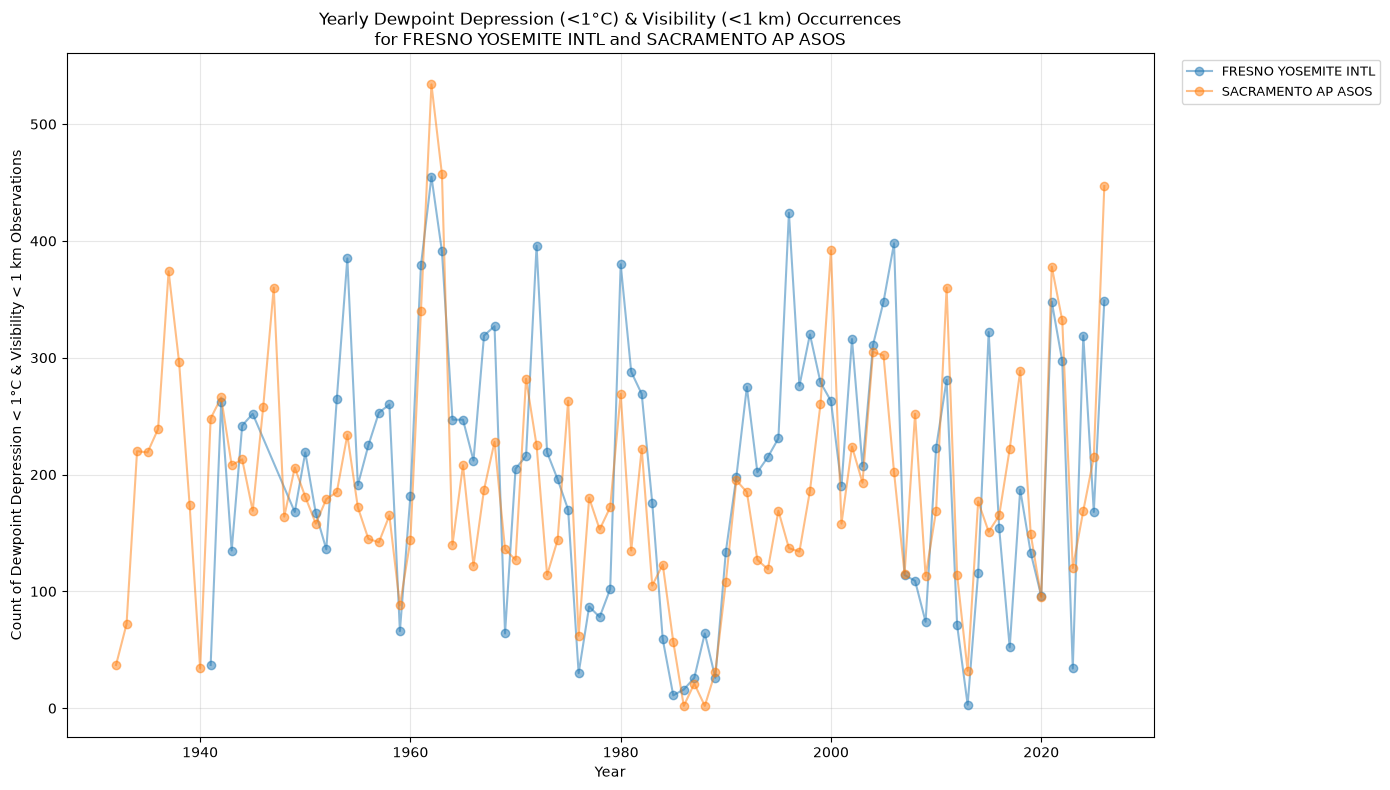

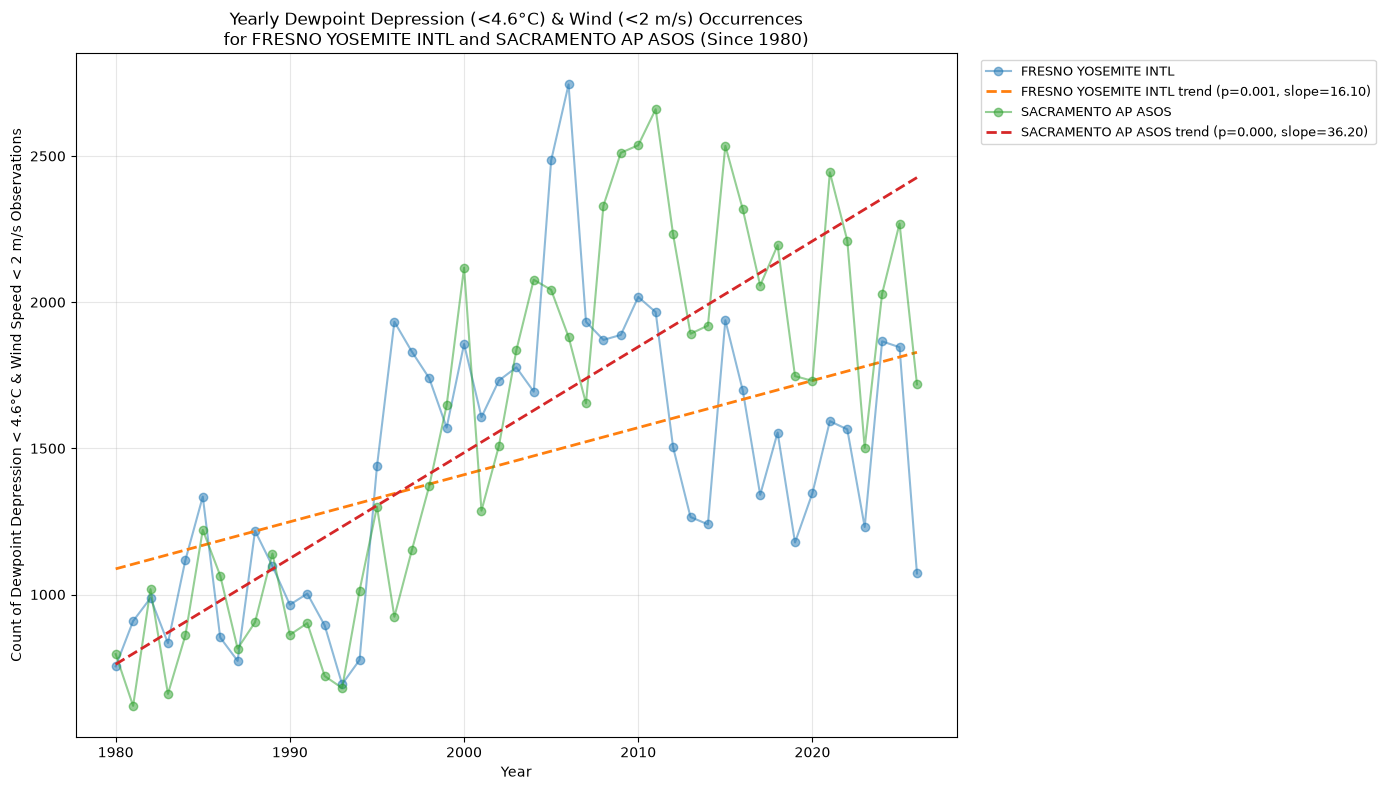


Total observations (selected stations): 767753
Observations with optimal fog conditions (DD < 4.6 & wind < 2 m/s): 215478
Percentage of optimal fog condition observations: 28.07%

Total unique days in selected data: 14310
Unique days with at least one optimal fog condition observation: 13232
Percentage of days with optimal fog conditions: 92.47%

Optimal-fog rows with visibility < 1 km: 26683 / 215478 = 12.38%
Optimal-fog days with visibility < 1 km: 3781 / 13232 = 28.57%

Station-level optimal fog summaries:

FRESNO YOSEMITE INTL
  Total obs: 363973
  Optimal obs: 103767 (28.51%)
  Total days: 12512
  Optimal days: 11037 (88.21%)

SACRAMENTO AP ASOS
  Total obs: 403780
  Optimal obs: 111711 (27.67%)
  Total days: 14310
  Optimal days: 11512 (80.45%)


In [22]:
# Repeat the fog analysis for only the FRESNO YOSEMITE INTL and SACRAMENTO AP ASOS stations

station_names = ["FRESNO YOSEMITE INTL", "SACRAMENTO AP ASOS"]

# Restrict the full dataset to the selected stations
CV_rows_selected = CV_rows[CV_rows["STATION"].isin(station_names)].copy()

# Ensure dewpoint depression exists
if "HourlyDewpointDepression" not in CV_rows_selected.columns:
    CV_rows_selected["HourlyDewpointDepression"] = (
        CV_rows_selected["HourlyDryBulbTemperature"] - CV_rows_selected["HourlyDewPointTemperature"]
    )

print("Selected station rows:", CV_rows_selected.shape)
print(CV_rows_selected["STATION"].value_counts())

# ------------------------------------------------------------------
# 1) Optimal fog condition filter: dewpoint depression < 4.6 and wind < 2
# ------------------------------------------------------------------
CV_rows_selected_dd_wind_filtered = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 4.6)
    & (CV_rows_selected["HourlyWindSpeed"] < 2.0)
].copy()

print("\nOptimal fog condition rows (DD < 4.6 & wind < 2 m/s):", CV_rows_selected_dd_wind_filtered.shape)

# ------------------------------------------------------------------
# 2) Visibility-based filters for multiple thresholds
# ------------------------------------------------------------------
CV_rows_selected_dd_filtered_5deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 5.0)
    & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_4deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 4.0)
    & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_3deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 3.0)
    & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_2deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 2.0)
    & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_1deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 1.0)
    & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

for name, df in {
    "CV_rows_selected_dd_filtered_5deg": CV_rows_selected_dd_filtered_5deg,
    "CV_rows_selected_dd_filtered_4deg": CV_rows_selected_dd_filtered_4deg,
    "CV_rows_selected_dd_filtered_3deg": CV_rows_selected_dd_filtered_3deg,
    "CV_rows_selected_dd_filtered_2deg": CV_rows_selected_dd_filtered_2deg,
    "CV_rows_selected_dd_filtered_1deg": CV_rows_selected_dd_filtered_1deg,
}.items():
    print(f"\n{name}: {df.shape}")

# ------------------------------------------------------------------
# 3) Station-level valley wind type summary
# ------------------------------------------------------------------
selected_valley_counts = (
    CV_rows_selected.groupby(["STATION", "valley_wind_type"])
    .size()
    .unstack(fill_value=0)
)

print("\nSelected station valley wind counts:")
print(selected_valley_counts)

# ------------------------------------------------------------------
# 4) Yearly counts and trend plots for the visibility-based threshold
# ------------------------------------------------------------------
# Use the 1-degree filter as the main "fog occurrence" count
yearly_counts_selected = (
    CV_rows_selected_dd_filtered_1deg.groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data = yearly_counts_selected[yearly_counts_selected["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=f"{station}")

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(
            x, trend_y, linestyle="--", linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})"
        )

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 1°C & Visibility < 1 km Observations")
ax.set_title(
    "Yearly Dewpoint Depression (<1°C) & Visibility (<1 km) Occurrences\nfor FRESNO YOSEMITE INTL and SACRAMENTO AP ASOS"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5) Yearly counts and trend plots for the wind-filtered analysis
# ------------------------------------------------------------------
yearly_counts_selected_wind = (
    CV_rows_selected_dd_wind_filtered[CV_rows_selected_dd_wind_filtered["year"] >= 1980]
    .groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data = yearly_counts_selected_wind[yearly_counts_selected_wind["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=f"{station}")

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(
            x, trend_y, linestyle="--", linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})"
        )

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 4.6°C & Wind Speed < 2 m/s Observations")
ax.set_title(
    "Yearly Dewpoint Depression (<4.6°C) & Wind (<2 m/s) Occurrences\nfor FRESNO YOSEMITE INTL and SACRAMENTO AP ASOS (Since 1980)"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 6) Optimal fog summary for the selected stations
# ------------------------------------------------------------------
total_obs_selected = CV_rows_selected.shape[0]
optimal_obs_selected = CV_rows_selected_dd_wind_filtered.shape[0]

print(f"\nTotal observations (selected stations): {total_obs_selected}")
print(f"Observations with optimal fog conditions (DD < 4.6 & wind < 2 m/s): {optimal_obs_selected}")
print(f"Percentage of optimal fog condition observations: {optimal_obs_selected / total_obs_selected * 100:.2f}%")

optimal_days_selected = CV_rows_selected_dd_wind_filtered[["year", "month", "day"]].drop_duplicates().shape[0]
total_days_selected = CV_rows_selected[["year", "month", "day"]].drop_duplicates().shape[0]

print(f"\nTotal unique days in selected data: {total_days_selected}")
print(f"Unique days with at least one optimal fog condition observation: {optimal_days_selected}")
print(f"Percentage of days with optimal fog conditions: {optimal_days_selected / total_days_selected * 100:.2f}%")

# Fraction of optimal-fog rows and days with visibility < 1 km
optimal_rows_selected = CV_rows_selected_dd_wind_filtered.copy()
vis_lt_1_rows_selected = optimal_rows_selected[optimal_rows_selected["HourlyVisibility"] < 1].copy()
frac_rows_vis_lt_1_selected = vis_lt_1_rows_selected.shape[0] / optimal_rows_selected.shape[0]

total_optimal_days_selected = optimal_rows_selected[["year", "month", "day"]].drop_duplicates().shape[0]
vis_lt_1_days_selected = vis_lt_1_rows_selected[["year", "month", "day"]].drop_duplicates().shape[0]
frac_days_vis_lt_1_selected = vis_lt_1_days_selected / total_optimal_days_selected

print(f"\nOptimal-fog rows with visibility < 1 km: {vis_lt_1_rows_selected.shape[0]} / {optimal_rows_selected.shape[0]} = {frac_rows_vis_lt_1_selected:.2%}")
print(f"Optimal-fog days with visibility < 1 km: {vis_lt_1_days_selected} / {total_optimal_days_selected} = {frac_days_vis_lt_1_selected:.2%}")

# ------------------------------------------------------------------
# 7) Add optional station-by-station breakdown
# ------------------------------------------------------------------
print("\nStation-level optimal fog summaries:")
for station in station_names:
    df_station = CV_rows_selected[CV_rows_selected["STATION"] == station]
    df_opt = CV_rows_selected_dd_wind_filtered[CV_rows_selected_dd_wind_filtered["STATION"] == station]
    total_obs = df_station.shape[0]
    optimal_obs = df_opt.shape[0]
    optimal_days = df_opt[["year", "month", "day"]].drop_duplicates().shape[0]
    total_days = df_station[["year", "month", "day"]].drop_duplicates().shape[0]
    print(f"\n{station}")
    print(f"  Total obs: {total_obs}")
    print(f"  Optimal obs: {optimal_obs} ({optimal_obs/total_obs*100:.2f}%)")
    print(f"  Total days: {total_days}")
    print(f"  Optimal days: {optimal_days} ({optimal_days/total_days*100:.2f}%)")

In [23]:
common_station_names = [
    "BAKERSFIELD AP",
    "FRESNO YOSEMITE INTL",
    "RED BLUFF MUNI AP",
    "SACRAMENTO AP ASOS",
    "STOCKTON AP",
    "TRAVIS FIELD AFB",
]

fog_rows_common = CV_rows_dd_filtered_1deg[
    CV_rows_dd_filtered_1deg["STATION"].isin(common_station_names)
].copy()

fog_rows_common["date"] = pd.to_datetime(
    fog_rows_common[["year", "month", "day"]]
)

# Summarize each station's fog observations by day
station_day_fog = (
    fog_rows_common
    .groupby(["date", "STATION"])
    .agg(
        first_observation=("DATE", "min"),
        last_observation=("DATE", "max"),
        fog_observations=("STATION", "size"),
    )
    .reset_index()
)

# Find dates affecting at least 5 of the 6 stations
common_fog_events = (
    station_day_fog
    .groupby("date")
    .agg(
        stations_with_fog=("STATION", "nunique"),
        stations=("STATION", lambda x: sorted(x.tolist())),
        total_fog_observations=("fog_observations", "sum"),
    )
    .reset_index()
)

common_fog_events = (
    common_fog_events[
        common_fog_events["stations_with_fog"] >= 5
    ]
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Common fog dates: {len(common_fog_events)}")
common_fog_events

Common fog dates: 408


,date,stations_with_fog,stations,total_fog_observations
0,1942-01-11,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",35
1,1942-01-15,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",30
2,1942-12-15,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",65
3,1942-12-16,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",73
4,1942-12-17,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",60
...,...,...,...,...
403,2026-01-20,6,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",104
404,2026-01-21,6,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",70
405,2026-01-22,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",83
406,2026-01-23,6,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",94


In [24]:
fog_days_per_year = (
    common_fog_events.assign(
        year=pd.to_datetime(common_fog_events["date"]).dt.year
    )
    .groupby("year")
    .size()
    .reset_index(name="fog_days")
)

fog_days_per_year

,year,fog_days
0,1942,5
1,1943,1
2,1944,8
3,1945,6
4,1949,7
...,...,...
61,2021,4
62,2022,4
63,2024,2
64,2025,4


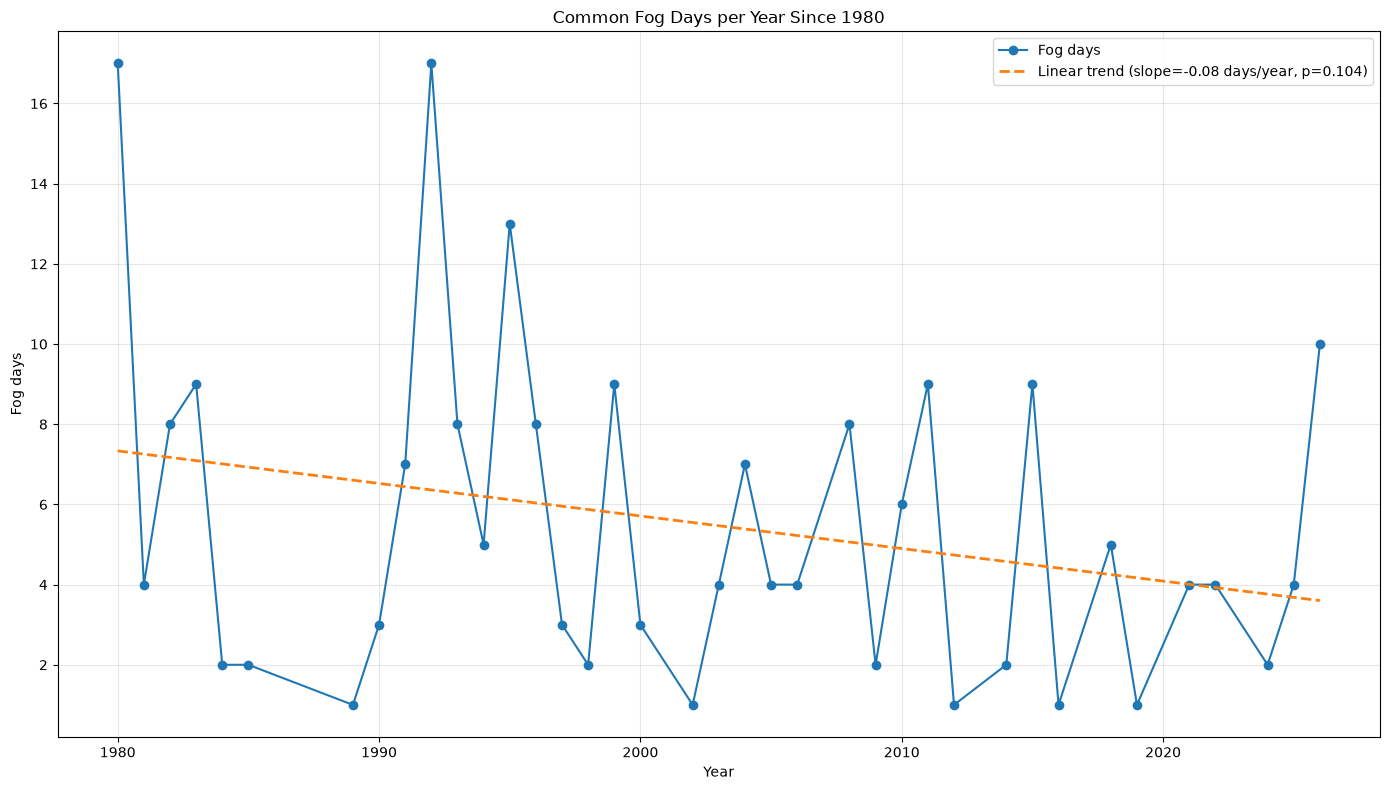

In [25]:
fog_days_since_1980 = fog_days_per_year[
    fog_days_per_year["year"] >= 1980
].sort_values("year")

x_fog = fog_days_since_1980["year"].to_numpy()
y_fog = fog_days_since_1980["fog_days"].to_numpy()

fog_slope, fog_intercept, _, fog_p_value, _ = stats.linregress(x_fog, y_fog)
fog_trend = fog_slope * x_fog + fog_intercept

fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(x_fog, y_fog, marker="o", linestyle="-", label="Fog days")
ax.plot(
    x_fog,
    fog_trend,
    linestyle="--",
    linewidth=2,
    label=f"Linear trend (slope={fog_slope:.2f} days/year, p={fog_p_value:.3f})"
)

ax.set_xlabel("Year")
ax.set_ylabel("Fog days")
ax.set_title("Common Fog Days per Year Since 1980")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()